In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,\
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
df = pd.read_csv('cleaned_25_feature_train.csv')
df

,CurrentEquipmentDays,MonthsInService,PercChangeMinutes,MonthlyMinutes,PercChangeRevenues,MonthlyRevenue,TotalRecurringCharge,PeakCallsInOut,OffPeakCallsInOut,ReceivedCalls,...,InboundCalls,CustomerCareCalls,RoamingCalls,DirectorAssistedCalls,ThreewayCalls,PrizmCode,HandsetRefurbished,HandsetWebCapable,ActiveSubs,Churn
0,361.0,61,-157.0,219.0,-19.0,24.00,22.0,58.0,24.0,97.2,...,0.0,0.0,0.0,0.25,0.0,2,0,1,1,1
1,1504.0,58,-4.0,10.0,0.0,16.99,17.0,5.0,1.0,0.0,...,0.0,0.0,0.0,0.00,0.0,2,0,0,1,1
2,1812.0,60,-2.0,8.0,0.0,38.00,38.0,1.3,3.7,0.4,...,0.0,0.0,0.0,0.00,0.0,3,0,0,1,0
3,458.0,59,157.0,1312.0,8.1,82.28,75.0,555.7,303.7,200.3,...,147.0,4.3,0.0,1.24,1.3,0,0,1,2,0
4,852.0,53,0.0,0.0,-0.2,17.14,17.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00,0.0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49668,883.0,30,0.0,76.0,0.0,0.00,30.0,29.3,17.0,11.2,...,0.0,0.7,0.0,0.00,0.0,0,0,1,1,0
49669,883.0,30,-38.0,63.0,-13.2,31.92,17.0,16.0,14.7,14.0,...,0.0,0.0,0.0,0.00,0.0,0,0,1,1,0
49670,882.0,30,-40.0,724.0,-2.0,71.99,70.0,262.0,12.7,70.2,...,0.3,0.0,0.9,0.00,1.7,0,0,0,1,0
49671,489.0,30,0.0,384.0,0.0,117.49,30.0,99.3,54.3,21.7,...,0.0,0.0,0.0,0.00,0.0,0,0,1,1,1


In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train : ", X_train.shape)
print("Shape of X_test : ", X_test.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of y_test : ", y_test.shape)

Shape of X_train :  (39738, 24)
Shape of X_test :  (9935, 24)
Shape of y_train :  (39738,)
Shape of y_test :  (9935,)


In [7]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


In [ ]:
# 1) Detect and remove anomalies from training set
iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,   
    random_state=42,
    n_jobs=-1
)
train_inlier_mask = iso.fit_predict(X_train) == 1

X_train_clean = X_train.loc[train_inlier_mask]
y_train_clean = y_train.loc[train_inlier_mask]

print(f"Original training size: {X_train.shape[0]}")
print(f"Cleaned training size : {X_train_clean.shape[0]}")
print(f"Removed anomalies     : {X_train.shape[0] - X_train_clean.shape[0]}")
print("-" * 50)
print("Target balance (before cleaning):")
print(y_train.value_counts(normalize=True).rename("ratio"))
print("\nTarget balance (after cleaning):")
print(y_train_clean.value_counts(normalize=True).rename("ratio"))


Original training size: 39738
Cleaned training size : 38545
Removed anomalies     : 1193
--------------------------------------------------
Target balance (before cleaning):
Churn
0    0.713524
1    0.286476
Name: ratio, dtype: float64

Target balance (after cleaning):
Churn
0    0.711817
1    0.288183
Name: ratio, dtype: float64


In [12]:

# 2) Define models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}


In [13]:

try:
    models["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb_available = True
except Exception:
    xgb_available = False
    print("\nXGBoost not available in environment. Skipping XGBoost model.")


In [14]:
# 3) Train + evaluate
results = []
trained_models = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train_clean, y_train_clean)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    })

    trained_models[name] = model
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)


In [15]:

# 4) Comparison table
results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
print("\nModel comparison:")
print(results_df)



Model comparison:
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0              XGBoost  0.718269   0.529785  0.146873  0.229986  0.662584
1        Random Forest  0.717564   0.528736  0.129304  0.207792  0.655666
2            SVM (RBF)  0.578259   0.358824  0.600141  0.449119  0.624390
3  Logistic Regression  0.577655   0.353005  0.569571  0.435870  0.600507


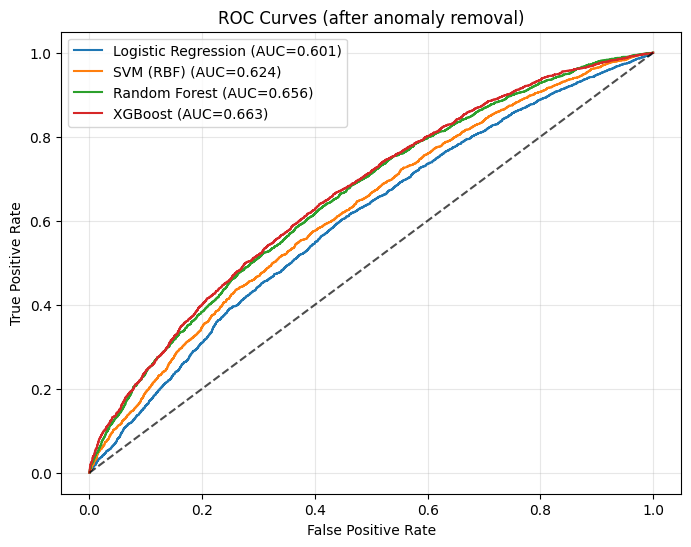

In [16]:

# 5) Plot ROC curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (after anomaly removal)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Best model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0     0.7345    0.9477    0.8276      7089
           1     0.5298    0.1469    0.2300      2846

    accuracy                         0.7183      9935
   macro avg     0.6322    0.5473    0.5288      9935
weighted avg     0.6759    0.7183    0.6564      9935



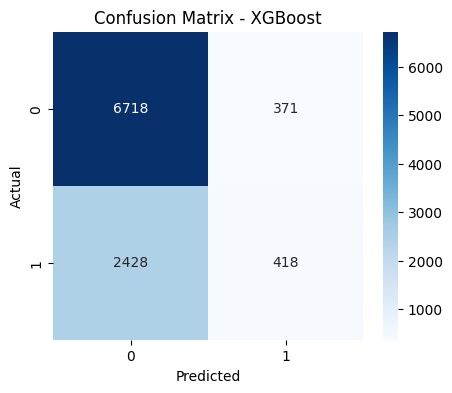

In [17]:

# 6) Detailed analysis of best model
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

print(f"\nBest model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()